In [17]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import os

In [18]:
os.makedirs('output', exist_ok=True)

# Series A filenames
filenames_a = {
    'rect1a': 'rect1a.tif',
    'rect2a': 'rect2a.tif',
    'rect3a': 'rect3a.tif',
    'rect4a': 'rect4a.tif',
}

series_a = {name: dip.ImageRead(fname) for name, fname in filenames_a.items()}


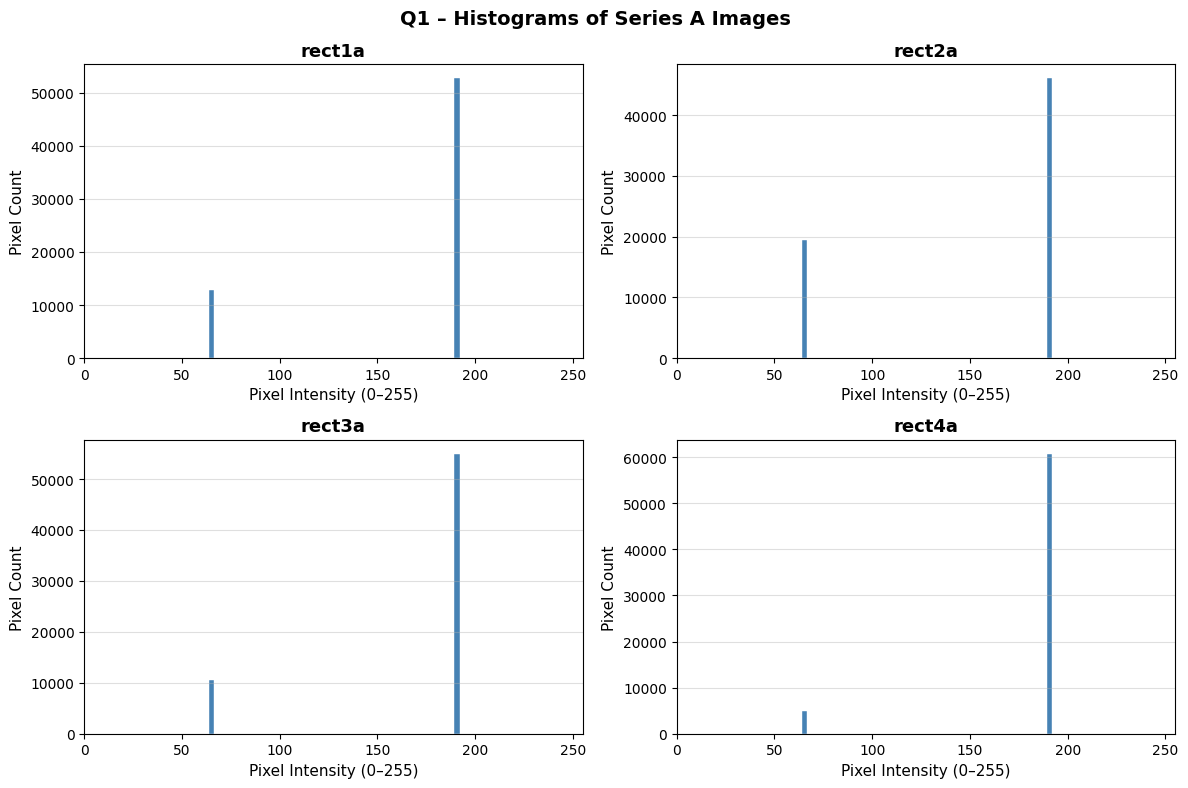

In [19]:
################################
# Q1: Histograms of Series A
################################

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, name in enumerate(sorted(series_a)):
    arr = np.array(series_a[name]).flatten()
    axes[idx].hist(arr, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Pixel Intensity (0–255)', fontsize=11)
    axes[idx].set_ylabel('Pixel Count', fontsize=11)
    axes[idx].set_xlim(0, 255)
    axes[idx].grid(axis='y', alpha=0.4)

fig.suptitle('Q1 – Histograms of Series A Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/q1_histograms_seriesA.png', bbox_inches='tight')
plt.show()


In [20]:
##############################################
# Q2: Measure area of each object per image
###############################################
results = {}

for name in sorted(series_a):
    img = series_a[name]

    # Threshold: IsodataThreshold returns a binary image
    bin_img = ~dip.IsodataThreshold(img)

    # Label connected components and measure areas
    labeled = dip.Label(bin_img, minSize=50)
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size'])
    areas = [msr[obj]['Size'][0] for obj in msr.Objects()]

    mean_area = np.mean(areas)
    std_area  = np.std(areas, ddof=1)

    results[name] = {'areas': areas, 'mean': mean_area, 'std': std_area, 'n': len(areas)}

    print(f"\n{name}:")
    print(f"  Individual areas (px²): {[round(a, 1) for a in areas]}")
    print(f"  Mean area : {mean_area:.2f} px²")
    print(f"  Std dev   : {std_area:.2f} px²")

# Summary table
print("\n── Q2 Summary Table ──────────────────────────────")
print(f"{'Image':<10} {'N objects':>10} {'Mean Area (px²)':>16} {'Std Dev (px²)':>14}")
print("-" * 54)
for name in sorted(results):
    r = results[name]
    print(f"{name:<10} {len(r['areas']):>10} {r['mean']:>16.2f} {r['std']:>14.2f}")


rect1a:
  Individual areas (px²): [12848.0]
  Mean area : 12848.00 px²
  Std dev   : nan px²

rect2a:
  Individual areas (px²): [3195.0, 3285.0, 3265.0, 3248.0, 3230.0, 3262.0]
  Mean area : 3247.50 px²
  Std dev   : 31.58 px²

rect3a:
  Individual areas (px²): [1320.0, 1328.0, 1335.0, 1304.0, 1340.0, 1309.0, 1297.0, 1360.0]
  Mean area : 1324.12 px²
  Std dev   : 20.90 px²

rect4a:
  Individual areas (px²): [475.0, 480.0, 480.0, 480.0, 486.0, 473.0, 468.0, 499.0, 484.0, 505.0]
  Mean area : 483.00 px²
  Std dev   : 11.38 px²

── Q2 Summary Table ──────────────────────────────
Image       N objects  Mean Area (px²)  Std Dev (px²)
------------------------------------------------------
rect1a              1         12848.00            nan
rect2a              6          3247.50          31.58
rect3a              8          1324.12          20.90
rect4a             10           483.00          11.38


c:\Users\emili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\emili\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
###################################################
# Q3: Measure perimeter of each object per image
####################################################
results_perim = {}

for name in sorted(series_a):
    img = series_a[name]

    # Same thresholding and labeling as Q2
    bin_img = ~dip.IsodataThreshold(img)
    labeled = dip.Label(bin_img, minSize=50)

    # Measure both Size and Perimeter in one call
    msr = dip.MeasurementTool.Measure(labeled, img, ['Size', 'Perimeter'])
    perims = [msr[obj]['Perimeter'][0] for obj in msr.Objects()]

    mean_p = np.mean(perims)
    std_p  = np.std(perims, ddof=1)

    results_perim[name] = {'n': len(perims), 'perims': perims,
                           'mean': mean_p, 'std': std_p}

    print(f"\n{name}:")
    print(f"  Individual perimeters (px): {[round(p, 1) for p in perims]}")
    print(f"  Mean perimeter : {mean_p:.2f} px")
    print(f"  Std dev        : {std_p:.2f} px")

# Summary table
print(f"\n{'Image':<10} {'N':>5} {'Mean Perimeter (px)':>20} {'Std Dev (px)':>14}")
print("-" * 54)
for name in sorted(results_perim):
    r = results_perim[name]
    std_str = f"{r['std']:>14.2f}" if r['n'] > 1 else "           N/A"
    print(f"{name:<10} {r['n']:>5} {r['mean']:>20.2f} {std_str}")


rect1a:
  Individual perimeters (px): [457.5]
  Mean perimeter : 457.50 px
  Std dev        : nan px

rect2a:
  Individual perimeters (px): [233.7, 230.1, 234.7, 236.0, 233.3, 235.1]
  Mean perimeter : 233.81 px
  Std dev        : 2.04 px

rect3a:
  Individual perimeters (px): [143.9, 148.8, 148.9, 146.9, 147.0, 147.5, 147.2, 150.5]
  Mean perimeter : 147.58 px
  Std dev        : 1.92 px

rect4a:
  Individual perimeters (px): [92.4, 91.0, 91.0, 92.9, 93.4, 92.0, 92.7, 93.5, 94.1, 95.2]
  Mean perimeter : 92.82 px
  Std dev        : 1.32 px

Image          N  Mean Perimeter (px)   Std Dev (px)
------------------------------------------------------
rect1a         1               457.50            N/A
rect2a         6               233.81           2.04
rect3a         8               147.58           1.92
rect4a        10                92.82           1.32


In [33]:
print(f"{'Image':<10} {'Object':>8} {'Area (px²)':>12} {'Perimeter (px)':>16}")
print("=" * 52)

for name in sorted(results):
    r_area = results[name]
    r_perim = results_perim[name]

    # One row per rectangle
    for i, (area, perim) in enumerate(zip(r_area['areas'], r_perim['perims'])):
        print(f"{name:<10} {i+1:>8} {area:>12.1f} {perim:>16.1f}")

    # Summary rows per image
    std_a = r_area['std']  if r_area['n'] > 1 else 0.0
    std_p = r_perim['std'] if r_perim['n'] > 1 else 0.0
    print(f"{'':10} {'Mean':>8} {r_area['mean']:>12.2f} {r_perim['mean']:>16.2f}")
    print(f"{'':10} {'Std Dev':>8} {std_a:>12.2f} {std_p:>16.2f}")
    print("-" * 52)

Image        Object   Area (px²)   Perimeter (px)
rect1a            1      12848.0            457.5
               Mean     12848.00           457.50
            Std Dev         0.00             0.00
----------------------------------------------------
rect2a            1       3195.0            233.7
rect2a            2       3285.0            230.1
rect2a            3       3265.0            234.7
rect2a            4       3248.0            236.0
rect2a            5       3230.0            233.3
rect2a            6       3262.0            235.1
               Mean      3247.50           233.81
            Std Dev        31.58             2.04
----------------------------------------------------
rect3a            1       1320.0            143.9
rect3a            2       1328.0            148.8
rect3a            3       1335.0            148.9
rect3a            4       1304.0            146.9
rect3a            5       1340.0            147.0
rect3a            6       1309.0            


── Q4: Area – Relative Discretization Error ───────────────
Image         Mean Area    Std Dev   √Mean Area     CV (σ/μ)
------------------------------------------------------------
rect2a          3247.50      31.58      56.9868       0.0097
rect3a          1324.12      20.90      36.3885       0.0158
rect4a           483.00      11.38      21.9773       0.0236


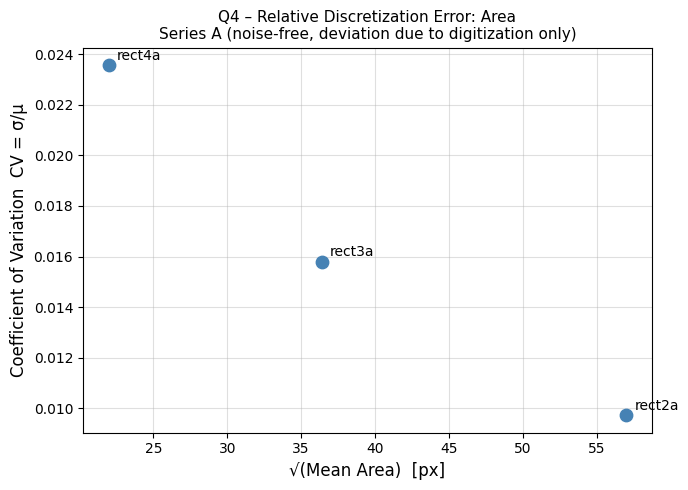

In [34]:
##############################################
# Q4: Relative discretization error – Area
##############################################

# Only use images with more than 1 object (need std dev)
names_valid = [n for n in sorted(results) if results[n]['n'] > 1]

sqrt_mean_area = [np.sqrt(results[n]['mean']) for n in names_valid]
cv_area        = [results[n]['std'] / results[n]['mean'] for n in names_valid]

# Print table
print("\n── Q4: Area – Relative Discretization Error ───────────────")
print(f"{'Image':<10} {'Mean Area':>12} {'Std Dev':>10} {'√Mean Area':>12} {'CV (σ/μ)':>12}")
print("-" * 60)
for n in names_valid:
    r = results[n]
    print(f"{n:<10} {r['mean']:>12.2f} {r['std']:>10.2f} "
          f"{np.sqrt(r['mean']):>12.4f} "
          f"{r['std']/r['mean']:>12.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqrt_mean_area, cv_area, color='steelblue', s=80, zorder=3)
for i, n in enumerate(names_valid):
    ax.annotate(n, (sqrt_mean_area[i], cv_area[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlabel('√(Mean Area)  [px]', fontsize=12)
ax.set_ylabel('Coefficient of Variation  CV = σ/μ', fontsize=12)
ax.set_title('Q4 – Relative Discretization Error: Area\n'
             'Series A (noise-free, deviation due to digitization only)', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/q4_discretization_area.png', bbox_inches='tight')
plt.show()


── Q5: Perimeter – Relative Discretization Error ──────────
Image        Mean Perim    Std Dev   √Mean Perim     CV (σ/μ)
--------------------------------------------------------------
rect2a           233.81       2.04       15.2909       0.0087
rect3a           147.58       1.92       12.1483       0.0130
rect4a            92.82       1.32        9.6345       0.0143


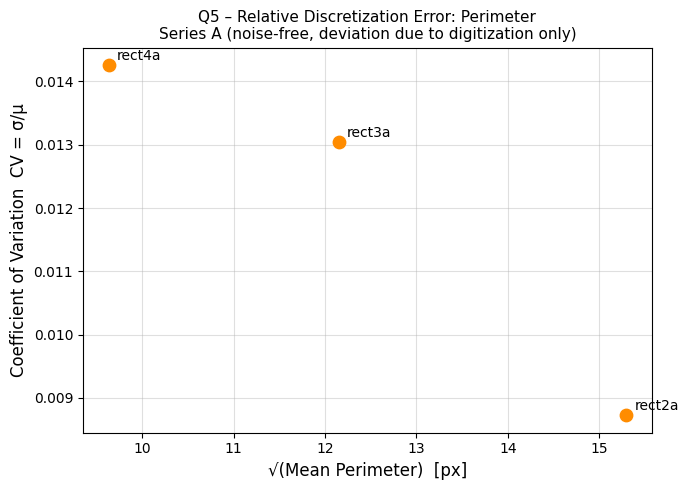

In [ ]:
##############################################
# Q5: Relative discretization error – Perimeter
##############################################

# Only use images with more than 1 object (need std dev)
names_valid = [n for n in sorted(results_perim) if results_perim[n]['n'] > 1]

sqrt_mean_perim = [np.sqrt(results_perim[n]['mean']) for n in names_valid]
cv_perim        = [results_perim[n]['std'] / results_perim[n]['mean'] for n in names_valid]

# Print table
print("\n── Q5: Perimeter – Relative Discretization Error ──────────")
print(f"{'Image':<10} {'Mean Perim':>12} {'Std Dev':>10} {'√Mean Perim':>13} {'CV (σ/μ)':>12}")
print("-" * 62)
for n in names_valid:
    r = results_perim[n]
    print(f"{n:<10} {r['mean']:>12.2f} {r['std']:>10.2f} "
          f"{np.sqrt(r['mean']):>13.4f} "
          f"{r['std']/r['mean']:>12.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sqrt_mean_perim, cv_perim, color='darkorange', s=80, zorder=3)
for i, n in enumerate(names_valid):
    ax.annotate(n, (sqrt_mean_perim[i], cv_perim[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlabel('√(Mean Perimeter)  [px]', fontsize=12)
ax.set_ylabel('Coefficient of Variation  CV = σ/μ', fontsize=12)
ax.set_title('Q5 – Relative Discretization Error: Perimeter\n'
             'Series A (noise-free, deviation due to digitization only)', fontsize=11)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('output/q5_discretization_perimeter.png', bbox_inches='tight')
plt.show()